# E-commerce Demand Forecasting

Forecast weekly demand per product **4 weeks** and **3 months (13 weeks)** ahead, with a **p90** upper range, for a promo planner a
product manager can use. Data: 320 products × 131 weeks (Jul 2022 – Dec 2024), synthetic Kaggle dataset.

> **Try it:** <a href="../#forecast-app" target="_top"><b>Open the promo planner →</b></a>  
> Pick a product or a whole category, a 4-week or 3-month horizon, and a 25%-off promo; see the forecast, the demand to plan for, and what the promo adds.

**Result** (rolling backtests, scored against true demand)

| | 4 weeks | 3 months |
|---|---|---|
| Model error, weekly (WAPE) | **15.2%** | **18.9%** |
| Best baseline, ETS included | 20.5% (ETS, seasonally adjusted) | 23.8% (level × season) |
| Error cut | −26% | −21% |
| Error on the horizon total | 11.3% | 13.2% |
| Error weighted by revenue | 16.2% | 19.5% |
| Error in Nov–Dec weeks | 13.4% | 20.3% |
| p90 of the total, coverage (one product) | 89.6% | 90.4% |

- **Stockouts distort history.** Training on raw sales under-forecasts by 4.9%; filling stockout weeks cuts that to 1.3%, within a hair of perfect demand history (1.2%).
- **The small overall bias is two opposite errors.** Healthy products run under (−3.9% / −7.2%, stockout risk); products in their final decline run over (+42% / +72%, dead-stock risk).
- **Plan buys on the p90 of the total, not the sum of weekly p90s.** The sum covers 96–97% of horizon totals instead of 90%.
- **Output:** `data/forecasts.csv` (every live product's forecast and weekly p90, promo off and on, plus return rate and sales trend) and `data/p90_factors.csv`, which feed the promo planner.

### Key ideas, in the order they appear
1. **No cheating (Step 3).** A forecast may only use what is known on forecast day. Sales, returns and stockouts of future weeks, and the dataset's hidden labels, are banned.
2. **Fill stockout weeks (Step 11).** A business knows when it was out of stock. Filling those weeks stops the model learning that demand collapsed.
3. **Features as of the forecast date, proven leak-free (Step 12).** Every input is built from weeks up to the cutoff. Scrambling every later week changes none of them.
4. **Judged against simple rules and ETS on honest backtests (Steps 13–16).** WAPE and bias against true demand, on rolling folds that include the November peak, vs three spreadsheet rules and two ETS models.
5. **The season is multiplied in, not learned from scratch (Step 14, 19).** The model learns demand relative to level × season, so peaks keep their full height.
6. **Stockout history costs accuracy, and filling wins it back (Step 15).** Raw sales: 17.6% error, −4.9% bias. Filled: 15.2%, −1.3%. Perfect history: 14.9%.
7. **Dying products are over-forecast by +42% (4 weeks) and +72% (3 months) (Steps 17, 20).** Nothing in their past warns of the decline; the overall bias looks small only because healthy products run under.
8. **Plan to the p90 of the total, not the sum of weekly p90s (Step 22).** The sum covers 96–97% of horizon totals instead of 90%.
9. **Promo forecasts are precomputed, and that is exact (Step 23).** A promo's lift doesn't carry into the next week, so each week forecast with the promo off and on covers every plan a PM can make.

---
# Phase 1 — Understand the data
*Descriptive only: nothing here is fitted on the test weeks.*

## Step 1 — Setup: seed, chart style, library versions

In [1]:
# Step 1 — imports, seed, chart style (same palette and title style as the Ticket Classifier notebook)
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from matplotlib.colors import LinearSegmentedColormap
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, Naive

import warnings
# Products not launched yet leave empty slices in early weeks; nanmean warns about them. Expected, so silenced.
warnings.filterwarnings("ignore", message="Mean of empty slice")
warnings.filterwarnings("ignore", message="invalid value encountered")
# ETS on the shortest histories has no degrees of freedom left for its own error estimate; forecasts are unaffected.
warnings.filterwarnings("ignore", message="divide by zero encountered in scalar divide")

SEED = 42
np.random.seed(SEED)
DATA = Path("data/ecommerce_demand_weekly.csv")
pd.set_option("display.width", 160)

SURFACE, INK, INK_2, MUTED, GRID, AXIS = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
DIVERGING = LinearSegmentedColormap.from_list("div", ["#2a78d6", "#f0efec", "#e34948"])
mpl.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_2, "xtick.color": MUTED, "ytick.color": INK_2,
    "axes.edgecolor": AXIS, "axes.linewidth": 0.8, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 13, "axes.titlecolor": INK,
    "legend.frameon": False,
})

def headline(ax, title, subtitle, hbar=False):
    """Left-aligned bold title with a one-line subtitle; hbar=True also tidies a horizontal bar chart."""
    ax.set_title(title, pad=24)
    ax.text(0, 1.03, subtitle, transform=ax.transAxes, fontsize=9.5, color=INK_2)
    if hbar:
        ax.grid(axis="y", visible=False)
        ax.tick_params(axis="y", length=0)

print(f"SEED = {SEED}")
print(" | ".join(f"{k} {v}" for k, v in {"python": sys.version.split()[0], "pandas": pd.__version__, "numpy": np.__version__,
      "scikit-learn": sklearn.__version__, "matplotlib": mpl.__version__, "seaborn": sns.__version__}.items()))

SEED = 42
python 3.11.14 | pandas 2.3.3 | numpy 2.4.6 | scikit-learn 1.9.1 | matplotlib 3.11.2 | seaborn 0.13.2


## Step 2 — Load the data: shape, types, gaps, summary statistics

In [2]:
# Step 2 — load and describe
df = pd.read_csv(DATA, parse_dates=["date"]).sort_values(["sku", "date"], ignore_index=True)
print(f"{len(df):,} rows × {df.shape[1]} columns · {df.sku.nunique()} products · {df.category.nunique()} categories · "
      f"{df.date.nunique()} weeks ({df.date.min():%d %b %Y} – {df.date.max():%d %b %Y})")
overview = pd.DataFrame({"dtype": df.dtypes.astype(str), "missing": df.isna().sum(), "unique": df.nunique()})
overview

24,310 rows × 16 columns · 320 products · 8 categories · 131 weeks (04 Jul 2022 – 30 Dec 2024)


,dtype,missing,unique
date,datetime64[ns],0,131
sku,object,0,320
category,object,0,8
region,object,0,5
units_sold,int64,0,227
true_demand,int64,0,227
price,float64,0,14
on_promo,int64,0,2
stockout,int64,0,2
returns,int64,0,74


In [3]:
# Step 2 (stats) — numeric summary
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
date,24310,2023-12-12 14:44:54.594817024,2022-07-04 00:00:00,2023-07-03 00:00:00,2023-12-18 00:00:00,2024-06-03 00:00:00,2024-12-30 00:00:00,NaN
units_sold,24310.0,42.954545,0.0,20.0,34.0,58.0,279.0,32.92483
true_demand,24310.0,44.612341,0.0,22.0,35.0,59.0,279.0,32.621677
price,24310.0,53.833299,11.25,20.0,35.0,60.0,180.0,48.284592
on_promo,24310.0,0.113369,0.0,0.0,0.0,0.0,1.0,0.31705
stockout,24310.0,0.043439,0.0,0.0,0.0,0.0,1.0,0.203847
returns,24310.0,4.428219,0.0,1.0,2.0,5.0,76.0,6.620444
seasonal_index,24310.0,1.07185,0.712,0.939,0.999,1.062,2.354,0.262574
is_new_launch,24310.0,0.105306,0.0,0.0,0.0,0.0,1.0,0.306954
is_declining,24310.0,0.073756,0.0,0.0,0.0,0.0,1.0,0.261378


*No missing values. Every product is a weekly series; price takes at most 2 values per product (regular and 25% off).*

## Step 3 — Which columns can a forecast use?
**Decision:** only what is known on the day the forecast is made. The target is `true_demand`.

> **Key idea 1 · no cheating**  
> A forecast can only use what is known on forecast day. A column that is filled in after the week happens (sales, returns, stockouts) or that only the data generator knows (`seasonal_index`, `is_declining`) would make backtest scores look better than any real forecast could be. Every column gets a role before any modelling starts, and the code refuses to continue if one is missing.

In [4]:
# Step 3 — leakage audit: when does each column become known?
ROLES = {
    "date": ("known ahead", "The calendar"), "sku": ("known ahead", "Product id"), "category": ("known ahead", "Product attribute"),
    "region": ("known ahead", "Fixed per product (its home market)"), "month": ("known ahead", "From the date"),
    "price": ("known ahead", "Regular price, or 25% off when a promo is planned"),
    "on_promo": ("known ahead", "Planned by the PM; the promo planner takes it as input"),
    "is_new_launch": ("known ahead", "Launch date is known, so weeks-since-launch is too"),
    "true_demand": ("target", "What customers wanted, including sales lost to stockouts"),
    "units_sold": ("history only", "Observed sales; capped in stockout weeks"),
    "stockout": ("history only", "Known afterwards; supply gaps are not planned"),
    "returns": ("history only", "Arrives after the sale"), "net_units": ("history only", "units_sold − returns"),
    "revenue": ("history only", "net_units × price"),
    "seasonal_index": ("generator internals", "The simulator's true seasonal multiplier; a real business never sees it"),
    "is_declining": ("generator internals", "Label for a product's final decline; unknown in advance"),
}
assert set(ROLES) == set(df.columns), "every column must be classified before modelling"
pd.DataFrame(ROLES, index=["role", "why"]).T.sort_values("role")

,role,why
seasonal_index,generator internals,The simulator's true seasonal multiplier; a re...
is_declining,generator internals,Label for a product's final decline; unknown i...
units_sold,history only,Observed sales; capped in stockout weeks
stockout,history only,Known afterwards; supply gaps are not planned
returns,history only,Arrives after the sale
net_units,history only,units_sold − returns
revenue,history only,net_units × price
date,known ahead,The calendar
sku,known ahead,Product id
category,known ahead,Product attribute


## Step 4 — The target: how is weekly demand distributed?

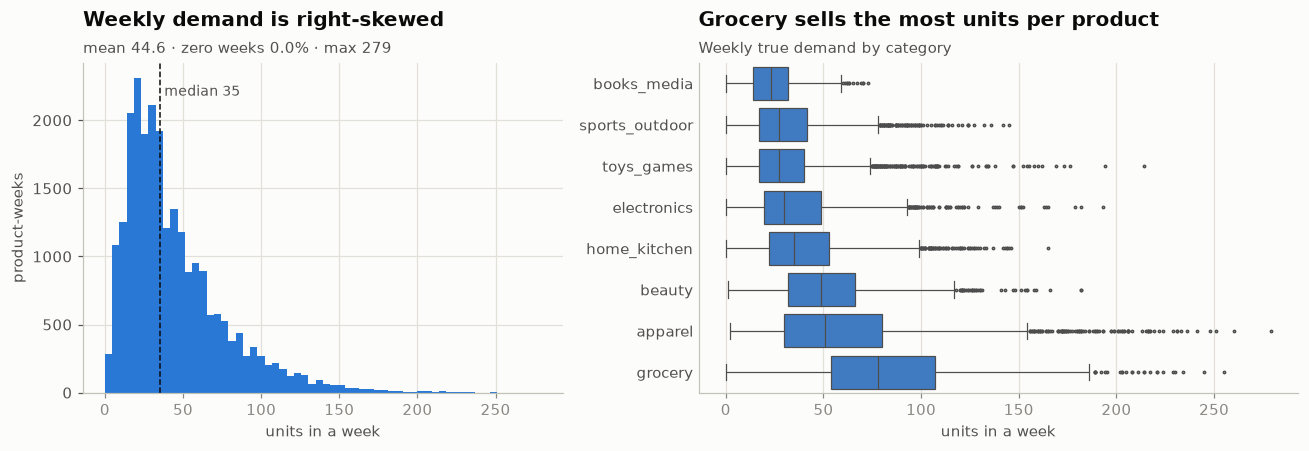

In [5]:
# Step 4 — distribution of weekly true demand, overall and by category
fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.2), gridspec_kw={"width_ratios": [1, 1.25]})
a1.hist(df.true_demand, bins=60, color=CAT[0])
a1.axvline(df.true_demand.median(), color=INK, lw=1, ls="--")
a1.text(df.true_demand.median() + 3, a1.get_ylim()[1] * 0.9, f"median {df.true_demand.median():.0f}", color=INK_2, fontsize=9)
a1.set_xlabel("units in a week"); a1.set_ylabel("product-weeks")
headline(a1, "Weekly demand is right-skewed", f"mean {df.true_demand.mean():.1f} · zero weeks {(df.true_demand == 0).mean():.1%} · max {df.true_demand.max()}")
order = df.groupby("category").true_demand.median().sort_values().index
sns.boxplot(data=df, y="category", x="true_demand", order=order, ax=a2, color=CAT[0], fliersize=1.5, linewidth=0.8)
a2.set_xlabel("units in a week"); a2.set_ylabel("")
headline(a2, "Grocery sells the most units per product", "Weekly true demand by category", hbar=True)
plt.tight_layout(); plt.show()

*Skewed, count-like target with almost no zero weeks → a Poisson loss fits it better than squared error.*

## Step 5 — Correlation between columns

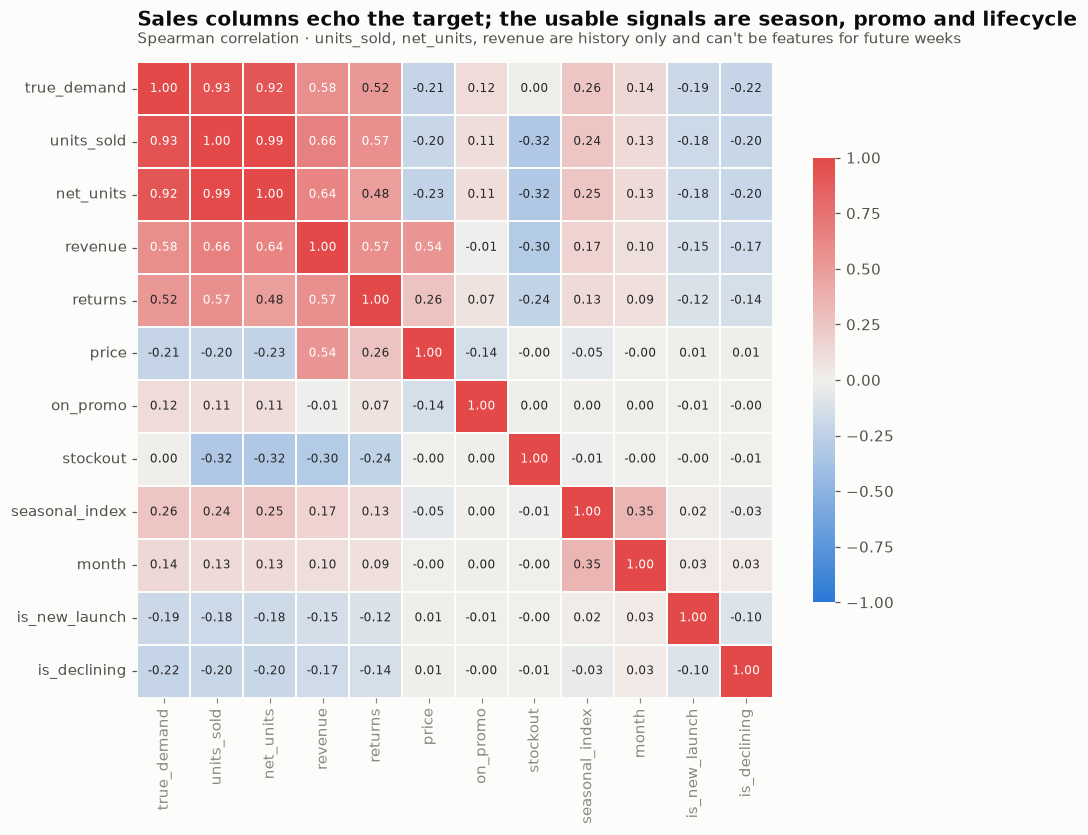

In [6]:
# Step 5 — Spearman correlation (rank-based, robust to the skew above)
num = ["true_demand", "units_sold", "net_units", "revenue", "returns", "price", "on_promo", "stockout",
       "seasonal_index", "month", "is_new_launch", "is_declining"]
corr = df[num].corr(method="spearman")
fig, ax = plt.subplots(figsize=(9.5, 7.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap=DIVERGING, vmin=-1, vmax=1, center=0, square=True,
            linewidths=1, linecolor=SURFACE, cbar_kws={"shrink": 0.7}, annot_kws={"size": 8}, ax=ax)
ax.grid(False)
headline(ax, "Sales columns echo the target; the usable signals are season, promo and lifecycle",
         "Spearman correlation · units_sold, net_units, revenue are history only and can't be features for future weeks")
plt.show()

*`units_sold` tracks `true_demand` at ~1.0 except in stockout weeks. Of the columns known ahead, `seasonal_index` (generator internals, not
usable), `on_promo` and lifecycle flags carry signal; `price` mostly separates categories.*

## Step 6 — Lifecycle: products launch, ramp, plateau and die

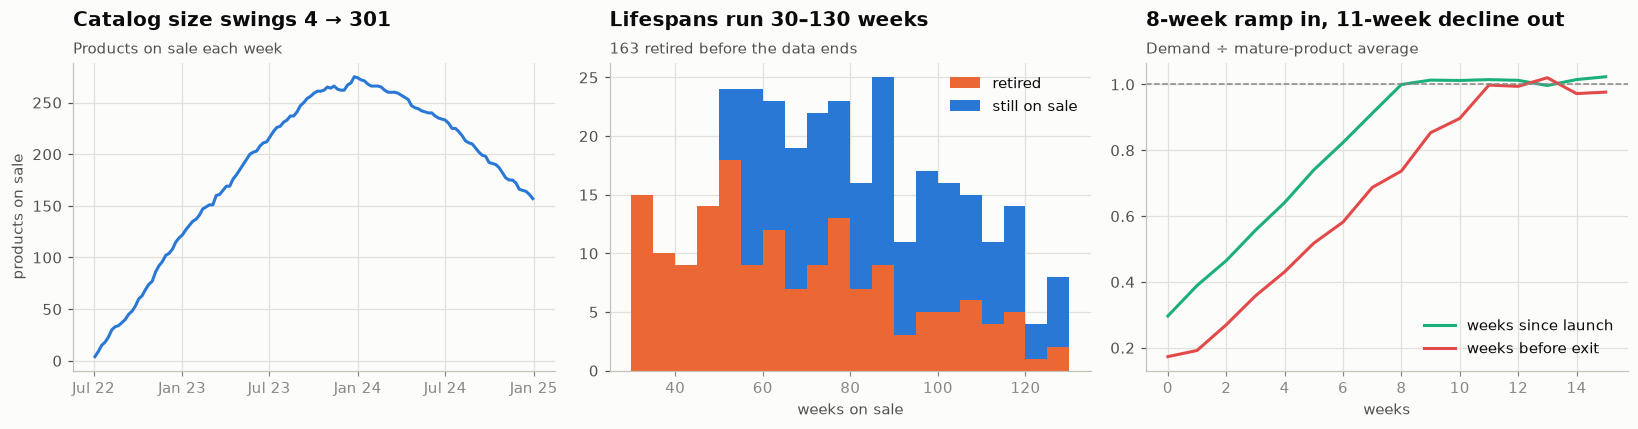

In [7]:
# Step 6 — catalog size over time, lifespans, and the average lifecycle curve
first, last = df.groupby("sku").date.min(), df.groupby("sku").date.max()
df["age"] = (df.date - df.sku.map(first)).dt.days // 7
df["to_exit"] = (df.sku.map(last) - df.date).dt.days // 7
retired = last < df.date.max()

fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 4))
on_sale = df.groupby("date").sku.size()
a1.plot(on_sale.index, on_sale.values, color=CAT[0], lw=2)
a1.set_ylabel("products on sale")
a1.xaxis.set_major_locator(mpl.dates.MonthLocator(bymonth=[1, 7]))
a1.xaxis.set_major_formatter(mpl.dates.DateFormatter("%b %y"))
headline(a1, "Catalog size swings 4 → 301", "Products on sale each week")
lifespan = df.groupby("sku").size()
a2.hist([lifespan[retired], lifespan[~retired]], bins=20, stacked=True, color=[CAT[1], CAT[0]], label=["retired", "still on sale"])
a2.set_xlabel("weeks on sale"); a2.legend()
headline(a2, "Lifespans run 30–130 weeks", f"{retired.sum()} retired before the data ends")
mature_level = df[(df.is_new_launch == 0) & (df.is_declining == 0)].true_demand.mean()
ramp = df[df.age < 16].groupby("age").true_demand.mean() / mature_level
exit_ = df[df.sku.map(retired) & (df.to_exit < 16)].groupby("to_exit").true_demand.mean() / mature_level
a3.plot(ramp.index, ramp.values, color=CAT[2], lw=2, label="weeks since launch")
a3.plot(exit_.index, exit_.values, color=CAT[7], lw=2, label="weeks before exit")
a3.axhline(1, color=MUTED, lw=1, ls="--"); a3.set_xlabel("weeks"); a3.legend()
headline(a3, "8-week ramp in, 11-week decline out", "Demand ÷ mature-product average")
plt.tight_layout(); plt.show()

*Two consequences: weeks-since-launch is a useful feature, and a product can start its final decline inside a 13-week horizon with nothing in its past to warn of it.*

## Step 7 — Seasonality by category

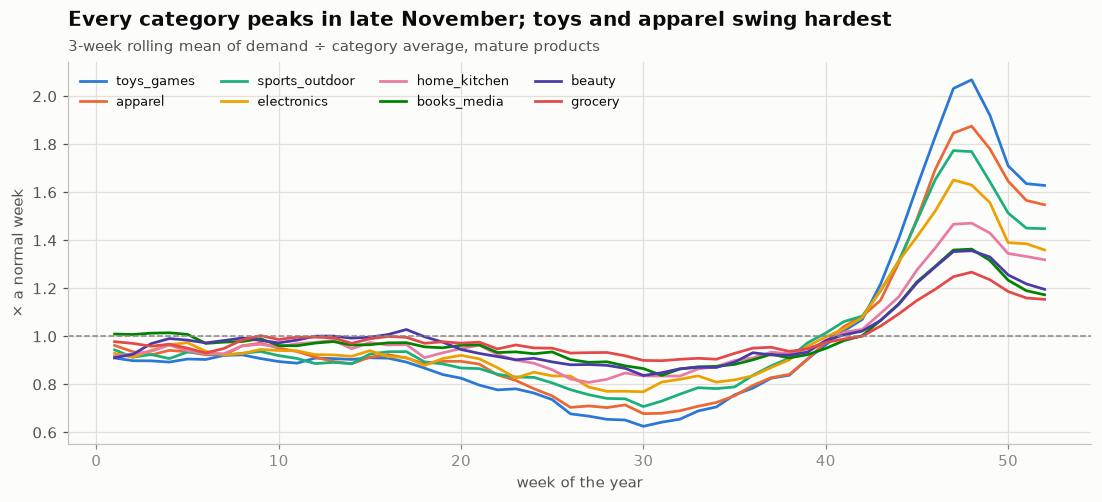

In [8]:
# Step 7 — mature products only, so launches and declines don't bend the curve
m = df[(df.is_new_launch == 0) & (df.is_declining == 0)].copy()
m["woy"] = m.date.dt.isocalendar().week.clip(upper=52)
prof = m.groupby(["category", "woy"]).true_demand.mean()
prof = (prof / prof.groupby("category").transform("mean")).unstack("category")
fig, ax = plt.subplots(figsize=(12, 4.5))
for i, c in enumerate(prof.max().sort_values(ascending=False).index):
    ax.plot(prof.index, prof[c].rolling(3, center=True, min_periods=1).mean(), color=CAT[i], lw=1.8, label=c)
ax.axhline(1, color=MUTED, lw=1, ls="--"); ax.set_xlabel("week of the year"); ax.set_ylabel("× a normal week")
ax.legend(ncol=4, loc="upper left", fontsize=8.5)
headline(ax, "Every category peaks in late November; toys and apparel swing hardest", "3-week rolling mean of demand ÷ category average, mature products")
plt.show()

## Step 8 — How far back does demand remember? (autocorrelation)

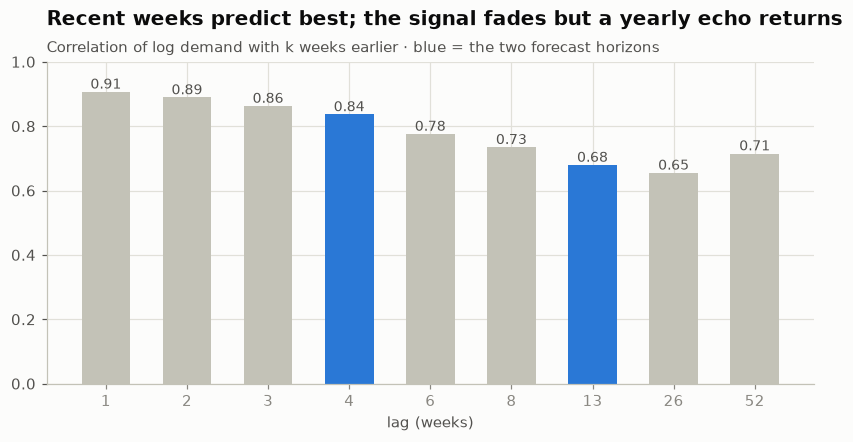

,1,2,3,4,6,8,13,26,52
correlation,0.907,0.889,0.863,0.836,0.776,0.734,0.679,0.655,0.715


In [9]:
# Step 8 — correlation of a product's demand with itself k weeks earlier (log scale, pooled over products)
lx = np.log1p(df.pivot(index="date", columns="sku", values="true_demand"))
lags = [1, 2, 3, 4, 6, 8, 13, 26, 52]
acf = pd.Series({k: pd.concat([lx.stack(), lx.shift(k).stack()], axis=1).dropna().corr().iloc[0, 1] for k in lags})
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.bar([str(k) for k in lags], acf.values, color=[CAT[0] if k in (4, 13) else AXIS for k in lags], width=0.6)
for i, v in enumerate(acf.values):
    ax.text(i, v + 0.01, f"{v:.2f}", ha="center", fontsize=9, color=INK_2)
ax.set_xlabel("lag (weeks)"); ax.set_ylim(0, 1)
headline(ax, "Recent weeks predict best; the signal fades but a yearly echo returns", "Correlation of log demand with k weeks earlier · blue = the two forecast horizons")
plt.show()
acf.round(3).to_frame("correlation").T

## Step 9 — Two things that bend the history: promos and stockouts

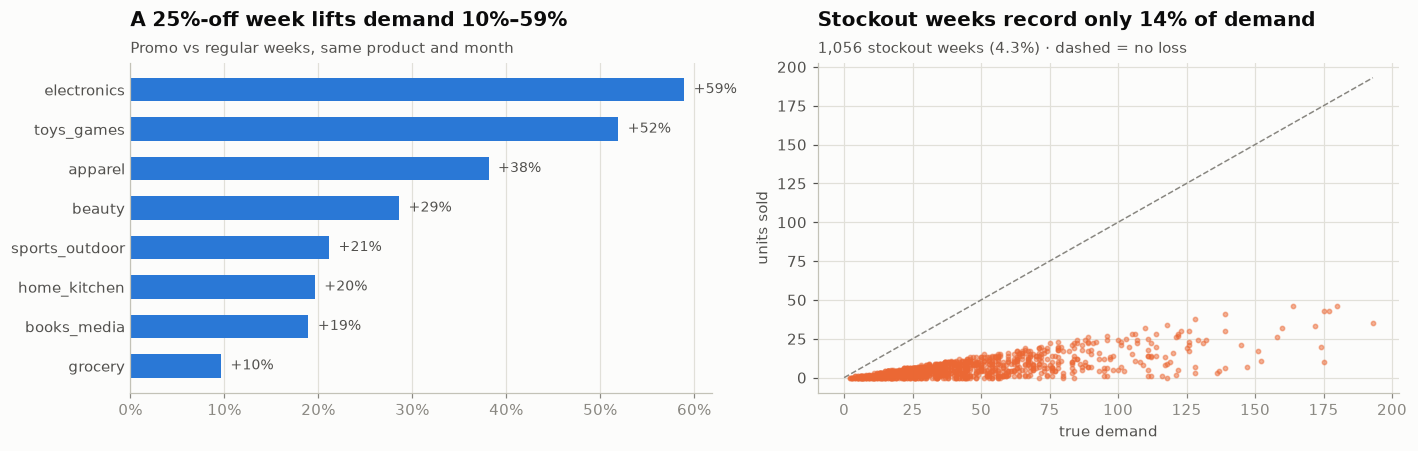

In [10]:
# Step 9 — promo uplift by category, and how much stockout weeks hide
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
cells = df.groupby(["category", "sku", df.date.dt.to_period("M"), "on_promo"]).true_demand.mean().unstack("on_promo").dropna()
lift = (cells[1].groupby("category").sum() / cells[0].groupby("category").sum() - 1).sort_values()
a1.barh(lift.index, lift.values, color=CAT[0], height=0.6)
for y, v in enumerate(lift.values):
    a1.text(v + 0.01, y, f"+{v:.0%}", va="center", fontsize=9, color=INK_2)
a1.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1))
headline(a1, f"A 25%-off week lifts demand {lift.min():.0%}–{lift.max():.0%}", "Promo vs regular weeks, same product and month", hbar=True)
so = df[df.stockout == 1]
a2.scatter(so.true_demand, so.units_sold, s=8, color=CAT[1], alpha=0.5)
lim = so.true_demand.max(); a2.plot([0, lim], [0, lim], color=MUTED, ls="--", lw=1)
a2.set_xlabel("true demand"); a2.set_ylabel("units sold")
headline(a2, f"Stockout weeks record only {so.units_sold.sum() / so.true_demand.sum():.0%} of demand",
         f"{len(so):,} stockout weeks ({df.stockout.mean():.1%}) · dashed = no loss")
plt.tight_layout(); plt.show()

*Promo lift varies by category, so the model gets category and promo together. Stockout weeks look like demand collapsed; a model trained on them learns to under-forecast.*

---
# Phase 2 — Preprocess

## Step 10 — Reshape to a product × week grid

In [11]:
# Step 10 — one row per product, one column per week; NaN where the product is not on sale
WEEKS = pd.DatetimeIndex(sorted(df.date.unique()))
SKUS = sorted(df.sku.unique())
wi, si = {d: i for i, d in enumerate(WEEKS)}, {s: i for i, s in enumerate(SKUS)}

def grid(col):
    g = np.full((len(SKUS), len(WEEKS)), np.nan)
    g[df.sku.map(si), df.date.map(wi)] = df[col].to_numpy(float)
    return g

UNITS, TRUE, STOCKOUT, PROMO = grid("units_sold"), grid("true_demand"), grid("stockout"), grid("on_promo")
ALIVE = ~np.isnan(UNITS)
info = df.groupby("sku").agg(category=("category", "first"), region=("region", "first"), price=("price", "max"))  # max = regular price
CATS = sorted(info.category.unique())
CAT_I = info.category.map({c: i for i, c in enumerate(CATS)}).to_numpy()
PRICE, FIRST = info.price.to_numpy(), ALIVE.argmax(axis=1)
WOY = WEEKS.isocalendar().week.to_numpy().clip(max=52)
print(f"grid {UNITS.shape[0]} products × {UNITS.shape[1]} weeks · {ALIVE.mean():.0%} of cells on sale")

grid 320 products × 131 weeks · 58% of cells on sale


## Step 11 — Fill stockout weeks (history only)
A real business knows which past weeks were out of stock. **Rule:** replace each stockout week with the product's average of its last 2
in-stock weeks. Only earlier weeks are used, so the fill never looks ahead.

> **Key idea 2 · fill stockout weeks**  
> A stockout week records only what was on the shelf (14% of real demand here), not what customers wanted. Left in, those weeks teach the model that demand collapsed, and it under-forecasts. A business knows which weeks it was out of stock, so it can fill them in. Step 15 measures what that is worth.

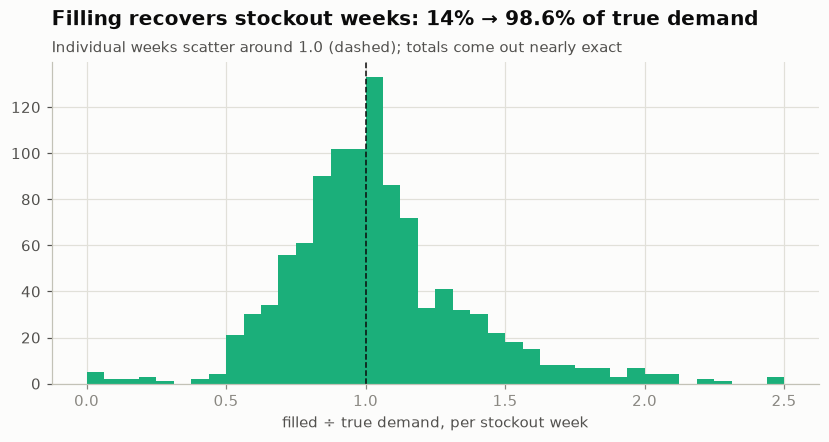

In [12]:
# Step 11 — fill_stockouts, then check it against the true demand the generator gives us
def fill_stockouts(units, stockout):
    filled = units.copy()
    for k in range(units.shape[0]):
        in_stock = []
        for w in range(units.shape[1]):
            if np.isnan(units[k, w]):
                continue
            if stockout[k, w] == 1 and in_stock:
                filled[k, w] = np.mean(in_stock[-2:])
            elif stockout[k, w] == 0:
                in_stock.append(units[k, w])
    return filled

FILLED = fill_stockouts(UNITS, STOCKOUT)
sw = STOCKOUT == 1
raw_share, fill_share = np.nansum(UNITS[sw]) / np.nansum(TRUE[sw]), np.nansum(FILLED[sw]) / np.nansum(TRUE[sw])
fig, ax = plt.subplots(figsize=(9, 3.8))
ratio = (FILLED[sw] / TRUE[sw])[np.isfinite(FILLED[sw] / TRUE[sw])]
ax.hist(ratio, bins=40, range=(0, 2.5), color=CAT[2])
ax.axvline(1, color=INK, lw=1, ls="--"); ax.set_xlabel("filled ÷ true demand, per stockout week")
headline(ax, f"Filling recovers stockout weeks: {raw_share:.0%} → {fill_share:.1%} of true demand",
         "Individual weeks scatter around 1.0 (dashed); totals come out nearly exact")
plt.show()

## Step 12 — Features, built as of each forecast date
**Decision:** `make_features(y, c, horizon)` uses only weeks ≤ cutoff `c`, including the seasonal factors. One row per
(product, cutoff, weeks ahead). The target week's promo flag is the only input from the future, and the PM supplies it.

> **Key idea 3 · what the model sees, and proof it can't see the future**  
> For each product, forecast date and target week the model gets: recent selling levels (4, 12, 26 weeks), the level with seasonality removed, a trend (last 4 ÷ last 12 weeks), the category's seasonal factor for the target week, the same week last year, weeks since launch, category, regular price, weeks ahead, and whether the target week is on promo. The check below scrambles every week after the cutoff with random numbers and rebuilds the features: if a single value changed, a feature would be reading the future.

In [13]:
# Step 12 — as-of-cutoff features
def season_factors(y, c):
    """Category × week-of-year factor from weeks <= c only; 1.0 for a week of the year not seen yet."""
    f = np.ones((len(CATS), 53))
    for k in range(len(CATS)):
        with np.errstate(all="ignore"):
            per_week = np.nanmean(y[CAT_I == k, : c + 1], axis=0)
        base = np.nanmean(per_week)
        for w in range(1, 53):
            v = per_week[WOY[: c + 1] == w]
            v = v[~np.isnan(v)]
            if len(v):
                f[k, w] = v.mean() / base
    return f

def make_features(y, c, horizon):
    k = np.where(ALIVE[:, c])[0]
    fk = season_factors(y, c)[CAT_I[k]]
    recent = lambda n: y[k, max(0, c - n + 1): c + 1]
    now_f = fk[:, WOY[max(0, c - 11): c + 1]]
    with np.errstate(all="ignore"):
        ds12 = np.nanmean(recent(12) / now_f, axis=1)
        ds4 = np.nanmean(recent(4) / now_f[:, -4:], axis=1)
        lvl = {n: np.nanmean(recent(n), axis=1) for n in (4, 12, 26)}
    rows = []
    for h in range(1, horizon + 1):
        t = c + h
        woy = WOY[t] if t < len(WEEKS) else (WOY[c] + h - 1) % 52 + 1
        rows.append(pd.DataFrame({
            "sku_i": k, "c": c, "h": h, "t": t, "cat": CAT_I[k], "woy": woy, "price": PRICE[k], "age": t - FIRST[k],
            "lvl4": lvl[4], "lvl12": lvl[12], "lvl26": lvl[26], "ds12": ds12, "trend": ds4 / ds12,
            "f_t": fk[:, woy], "seasonal": ds12 * fk[:, woy], "last_year": y[k, t - 52] if t >= 52 else np.nan,
        }))
    return pd.concat(rows, ignore_index=True)

FEATS = ["cat", "h", "woy", "promo", "price", "age", "lvl4", "lvl12", "lvl26", "ds12", "trend", "f_t", "seasonal", "last_year"]
FEATURE_NOTES = {
    "cat": "category", "h": "weeks ahead", "woy": "week of year of the target week", "promo": "target week on promo (PM input)",
    "price": "regular price", "age": "weeks since launch at the target week", "lvl4 / lvl12 / lvl26": "mean of the last 4 / 12 / 26 weeks",
    "ds12": "last-12-week level with seasonality removed", "trend": "last 4 ÷ last 12 weeks, seasonality removed",
    "f_t": "category seasonal factor for the target week", "seasonal": "ds12 × f_t (a ready-made seasonal forecast)",
    "last_year": "same week 52 weeks earlier (missing for young products)",
}
pd.Series(FEATURE_NOTES, name="meaning").to_frame()

,meaning
cat,category
h,weeks ahead
woy,week of year of the target week
promo,target week on promo (PM input)
price,regular price
age,weeks since launch at the target week
lvl4 / lvl12 / lvl26,mean of the last 4 / 12 / 26 weeks
ds12,last-12-week level with seasonality removed
trend,"last 4 ÷ last 12 weeks, seasonality removed"
f_t,category seasonal factor for the target week


In [14]:
# Step 12 (check) — no look-ahead: scrambling every week after the cutoff must not change a single feature
c_test = wi[pd.Timestamp("2024-03-04")]
scrambled = FILLED.copy()
scrambled[:, c_test + 1:] = np.random.default_rng(SEED).uniform(0, 500, scrambled[:, c_test + 1:].shape)
a, b = make_features(FILLED, c_test, 13), make_features(scrambled, c_test, 13)
cols = [f for f in FEATS if f != "promo"]  # promo is PM input, not built here
assert np.allclose(a[cols].fillna(-1), b[cols].fillna(-1)), "a feature reads the future"
print(f"no look-ahead: {len(a):,} feature rows identical with the future scrambled ✓")

no look-ahead: 3,380 feature rows identical with the future scrambled ✓


4-week feature rows: 93,376


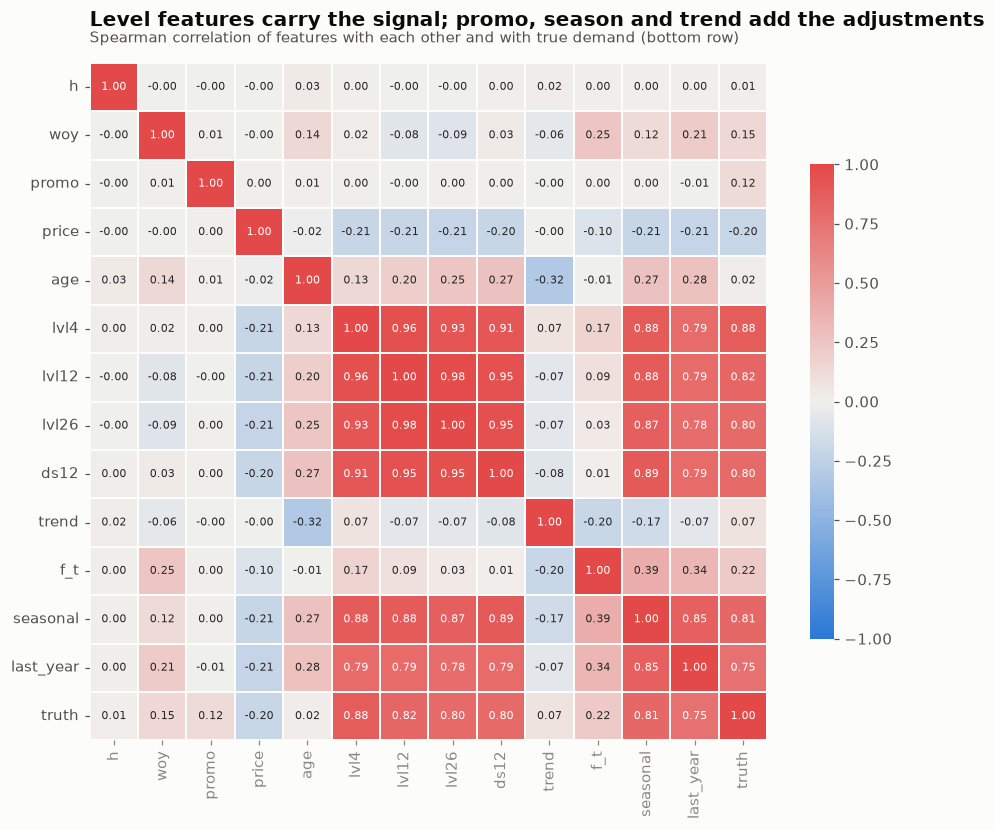

In [15]:
# Step 12 (rows) — attach promo (PM input), the training target, and the truth used for scoring
def features_all(y, horizon):
    return pd.concat([make_features(y, c, horizon) for c in range(8, len(WEEKS) - 1)], ignore_index=True)

def attach(X, y):
    X = X[X.t < len(WEEKS)].copy()
    k, t = X.sku_i.to_numpy(), X.t.to_numpy()
    X["promo"], X["y"], X["truth"] = PROMO[k, t], y[k, t], TRUE[k, t]
    return X[~np.isnan(X.truth)].reset_index(drop=True)

ROWS = {("B", 4): attach(features_all(FILLED, 4), FILLED)}
X4 = ROWS[("B", 4)]
print(f"4-week feature rows: {len(X4):,}")
fc = X4[FEATS + ["truth"]].drop(columns="cat").corr(method="spearman")
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(fc, annot=True, fmt=".2f", cmap=DIVERGING, vmin=-1, vmax=1, center=0, square=True, linewidths=1,
            linecolor=SURFACE, cbar_kws={"shrink": 0.7}, annot_kws={"size": 7.5}, ax=ax)
ax.grid(False)
headline(ax, "Level features carry the signal; promo, season and trend add the adjustments", "Spearman correlation of features with each other and with true demand (bottom row)")
plt.show()

---
# Phase 3 — Pre-modelling: how models are judged (fixed before training)

**Metrics:** WAPE = share of units missed, Σ|actual − forecast| ÷ Σ actual. Bias = over (+) or under (−) forecast as a share of actual.
Both are scored against `true_demand`, whatever the model was trained on.

**Backtest:** rolling cutoffs. Each model trains only on weeks up to its cutoff and forecasts the next 4 or 13 weeks.

> **Key idea 4 · how the models are compared**  
> Every candidate (the model trained three ways; three simple rules: last 4 weeks' average, level × season, same week last year; and two ETS models, Step 14b) is scored the same way: **WAPE** (share of units missed) and **bias** (over or under), against true demand, on the same rolling folds. A model earns its place only by beating the rules a planner could run in a spreadsheet and the standard statistical method.

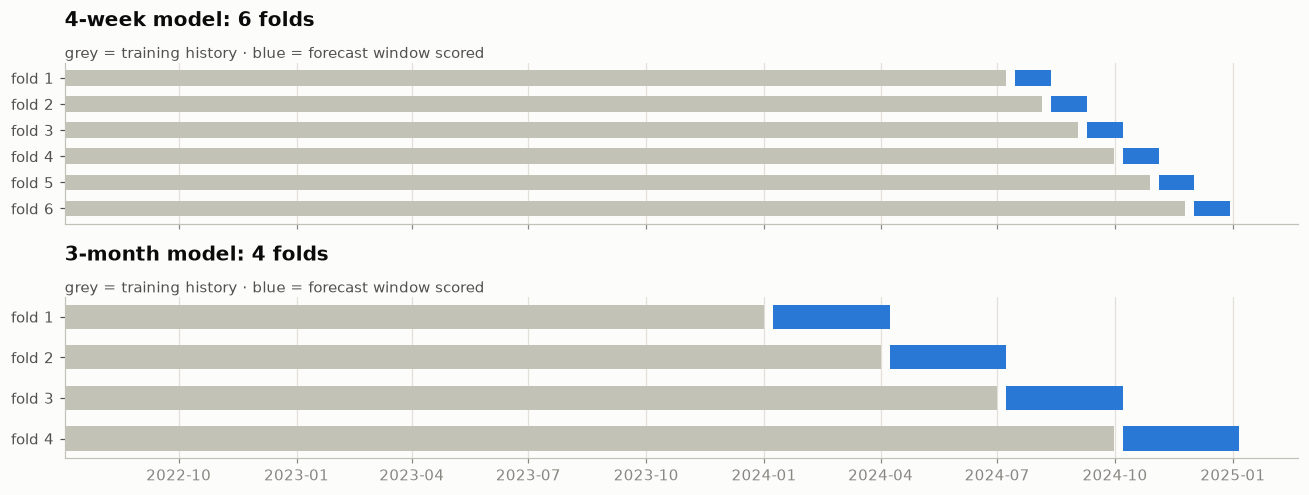

In [16]:
# Step 13 — backtest folds: every test window covers peak season at least once
wape = lambda y, p: np.abs(y - p).sum() / y.sum()
bias = lambda y, p: (p - y).sum() / y.sum()
FOLDS = {4: [wi[pd.Timestamp("2024-07-08")] + 4 * i for i in range(6)],
         13: [wi[pd.Timestamp(d)] for d in ["2024-01-01", "2024-04-01", "2024-07-01", "2024-09-30"]]}
fig, axes = plt.subplots(2, 1, figsize=(12, 4.6), sharex=True)
for ax, (H, cuts) in zip(axes, FOLDS.items()):
    for i, c in enumerate(cuts):
        ax.barh(i, (WEEKS[c] - WEEKS[0]).days, left=WEEKS[0], color=AXIS, height=0.6)
        ax.barh(i, H * 7, left=WEEKS[c] + pd.Timedelta(days=7), color=CAT[0], height=0.6)
    ax.set_yticks(range(len(cuts)), [f"fold {i + 1}" for i in range(len(cuts))]); ax.invert_yaxis(); ax.grid(axis="y", visible=False)
    headline(ax, f"{'4-week' if H == 4 else '3-month'} model: {len(cuts)} folds", "grey = training history · blue = forecast window scored")
plt.tight_layout(); plt.show()

In [17]:
# Step 14 — baselines a model has to beat
def baselines(r):
    out = {"last 4 weeks": r.lvl4, "seasonal (level × season)": r.seasonal, "same week last year": r.last_year.fillna(r.seasonal)}
    if "ets_adj" in r:  # added once Step 14b has run
        out |= {"ETS, season 52": r.ets52, "ETS, seasonally adjusted": r.ets_adj}
    return out

def base(X):
    """The seasonal forecast (recent level × season factor). Models learn demand relative to it; falls back to the 4-week level."""
    return X.seasonal.fillna(X.lvl4)

def fit(X, quantile=None, relative=True):
    """relative=True: learn demand ÷ seasonal forecast, so the season is multiplied back in exactly (see the decision below)."""
    loss = dict(loss="quantile", quantile=quantile) if quantile else dict(loss="poisson")
    X = X[X.seasonal > 0] if relative else X
    target = X.y / X.seasonal if relative else X.y
    m = HistGradientBoostingRegressor(max_iter=300, learning_rate=0.05, categorical_features=[0], random_state=SEED, **loss).fit(X[FEATS], target)
    m.relative = relative
    return m

def predict(m, X):
    return m.predict(X[FEATS]) * (base(X) if m.relative else 1)

def backtest(X, cutoffs, p90=False):
    out = []
    for C in cutoffs:
        test = X[X.c == C].copy()
        train = X[X.t <= C]
        test["pred"] = predict(fit(train), test)
        if p90:
            test["p90"] = predict(fit(train, 0.9), test)
        out.append(test)
    return pd.concat(out, ignore_index=True)

def score(r, cols):
    return pd.DataFrame({n: {"WAPE": wape(r.truth, p), "bias": bias(r.truth, p)} for n, p in cols.items()}).T

score(X4[X4.c.isin(FOLDS[4])], baselines(X4[X4.c.isin(FOLDS[4])])).style.format("{:+.1%}", subset="bias").format("{:.1%}", subset="WAPE")

,WAPE,bias
last 4 weeks,21.6%,-5.3%
seasonal (level × season),22.1%,+2.6%
same week last year,28.5%,-3.1%


**Decision: the model learns demand *relative to the seasonal forecast*.** The `seasonal` feature is a ready-made forecast: recent level with
seasonality removed, times the category's season factor for the target week. Asked to predict demand directly, the trees have to rebuild that
multiplication from splits, and they pull big seasonal swings toward the average. Predicting demand ÷ seasonal forecast, then multiplying back,
keeps the season at full size and lets the model spend its effort on promo, trend and lifecycle. Step 19 shows the difference on the November peak.

> **Key idea 5 · the season is multiplied in, not learned from scratch**  
> Learning demand relative to level × season keeps seasonal peaks at full height. Learning demand directly kept only about half of the November
> rise in the 3-month backtest (Step 19).

## Step 14b — The standard statistical baseline: ETS
Supply-chain teams usually benchmark against **exponential smoothing (ETS)**, fitted per product. Two versions, both on the filled history up to
each cutoff: **AutoETS with a 52-week season** (the textbook setup; products too short to fit fall back to last week's value), and **ETS on
seasonally adjusted demand** (divide out the category's seasonal factor, smooth, multiply it back), a common practical fix for short histories.

In [18]:
# Step 14b — ETS forecasts for every backtest fold (statsforecast, one product at a time)
def ets_forecast(C, H):
    k = np.where(ALIVE[:, C])[0]
    f = season_factors(FILLED, C)
    raw, adj = [], []
    for i in k:
        w = np.arange(FIRST[i], C + 1)
        y = FILLED[i, w]; ok = ~np.isnan(y); w, y = w[ok], y[ok]
        raw.append(pd.DataFrame({"unique_id": i, "ds": WEEKS[w], "y": y}))
        adj.append(pd.DataFrame({"unique_id": i, "ds": WEEKS[w], "y": y / f[CAT_I[i], WOY[w]]}))
    out = []
    for name, data, season in [("ets52", raw, 52), ("ets_adj", adj, 1)]:
        fc = StatsForecast(models=[AutoETS(season_length=season)], freq="W-MON", n_jobs=1, fallback_model=Naive()).forecast(df=pd.concat(data), h=H)
        fc = fc.reset_index() if "unique_id" not in fc.columns else fc
        fc["t"] = C + fc.groupby("unique_id").cumcount() + 1
        out.append(fc.rename(columns={"unique_id": "sku_i", "AutoETS": name})[["sku_i", "t", name]])
    e = out[0].merge(out[1], on=["sku_i", "t"]).assign(c=C)
    woy = WOY[np.minimum(e.t, len(WEEKS) - 1)]  # backtest targets are always inside the data
    e["ets_adj"] = e.ets_adj * f[CAT_I[e.sku_i.to_numpy()], woy]
    return e

ETS = {H: pd.concat([ets_forecast(C, H) for C in FOLDS[H]], ignore_index=True) for H in (4, 13)}
young = (FOLDS[13][0] - FIRST[ALIVE[:, FOLDS[13][0]]] + 1 < 104).mean()
print(f"products on sale at the Jan 2024 cutoff with under 2 years of history: {young:.0%}")
r = X4[X4.c.isin(FOLDS[4])].merge(ETS[4], on=["sku_i", "c", "t"])
score(r, baselines(r)).style.format("{:+.1%}", subset="bias").format("{:.1%}", subset="WAPE")

products on sale at the Jan 2024 cutoff with under 2 years of history: 100%


,WAPE,bias
last 4 weeks,21.6%,-5.3%
seasonal (level × season),22.1%,+2.6%
same week last year,28.5%,-3.1%
"ETS, season 52",22.0%,-3.6%
"ETS, seasonally adjusted",20.5%,+1.6%


*A 52-week seasonal ETS needs two full years per product to learn the season, and no product here has that. Seasonally adjusted ETS borrows the season from the category and becomes the strongest baseline at 4 weeks. The global model goes further: it learns season, promo and lifecycle across all products at once.*

---
# Phase 4 — 4-week model

## Step 15 — Does training on stockout-capped history hurt?
Three training targets, same model, all scored against true demand: **A** raw `units_sold` · **B** stockout weeks filled (Step 11) ·
**C** `true_demand` itself (best case — a real business never has it).

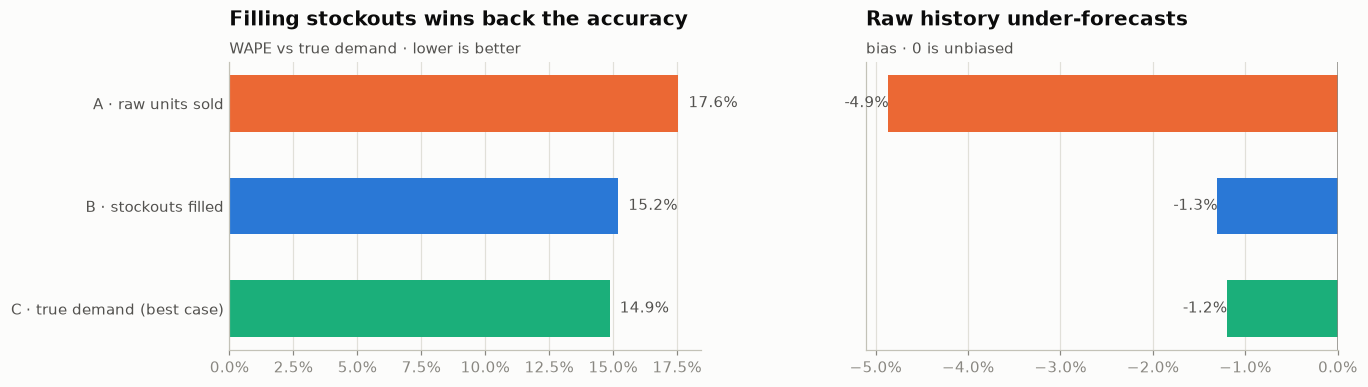

,WAPE,bias
A · raw units sold,17.6%,-4.9%
B · stockouts filled,15.2%,-1.3%
C · true demand (best case),14.9%,-1.2%


In [19]:
# Step 15 — A / B / C
ROWS[("A", 4)] = attach(features_all(UNITS, 4), UNITS)
ROWS[("C", 4)] = attach(features_all(TRUE, 4), TRUE)
RUNS = {name: backtest(ROWS[(key, 4)], FOLDS[4], p90=(key == "B")) for key, name in
        [("A", "A · raw units sold"), ("B", "B · stockouts filled"), ("C", "C · true demand (best case)")]}
abc = pd.DataFrame({n: {"WAPE": wape(r.truth, r.pred), "bias": bias(r.truth, r.pred)} for n, r in RUNS.items()}).T
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 3.4), sharey=True, gridspec_kw={"wspace": 0.35})
for ax, col, fmt in [(a1, "WAPE", "{:.1%}"), (a2, "bias", "{:+.1%}")]:
    ax.barh(abc.index[::-1], abc[col][::-1], color=[CAT[2], CAT[0], CAT[1]], height=0.55)
    for y, v in enumerate(abc[col][::-1]):
        ax.text(v, y, "  " + fmt.format(v), va="center", fontsize=9.5, color=INK_2, ha="left" if v >= 0 else "right")
    ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1))
headline(a1, "Filling stockouts wins back the accuracy", "WAPE vs true demand · lower is better", hbar=True)
headline(a2, "Raw history under-forecasts", "bias · 0 is unbiased", hbar=True)
a2.axvline(0, color=MUTED, lw=1)
plt.show()
abc.style.format({"WAPE": "{:.1%}", "bias": "{:+.1%}"})

**Decision:** train every model on **B** (stockouts filled). It is what a real business can build, and it lands within a hair of the best case.

> **Key idea 6 · stockout history costs accuracy, and filling wins it back**  
> Raw sales: 17.6% error and a −4.9% under-forecast. Filled: 15.2% and −1.3%. Perfect demand history: 14.9% and −1.2%.

## Step 16 — Model vs baselines, by weeks ahead and by category

,WAPE,bias
model,15.2%,-1.3%
last 4 weeks,21.6%,-5.3%
seasonal (level × season),22.1%,+2.6%
same week last year,28.5%,-3.1%
"ETS, season 52",22.0%,-3.6%
"ETS, seasonally adjusted",20.5%,+1.6%


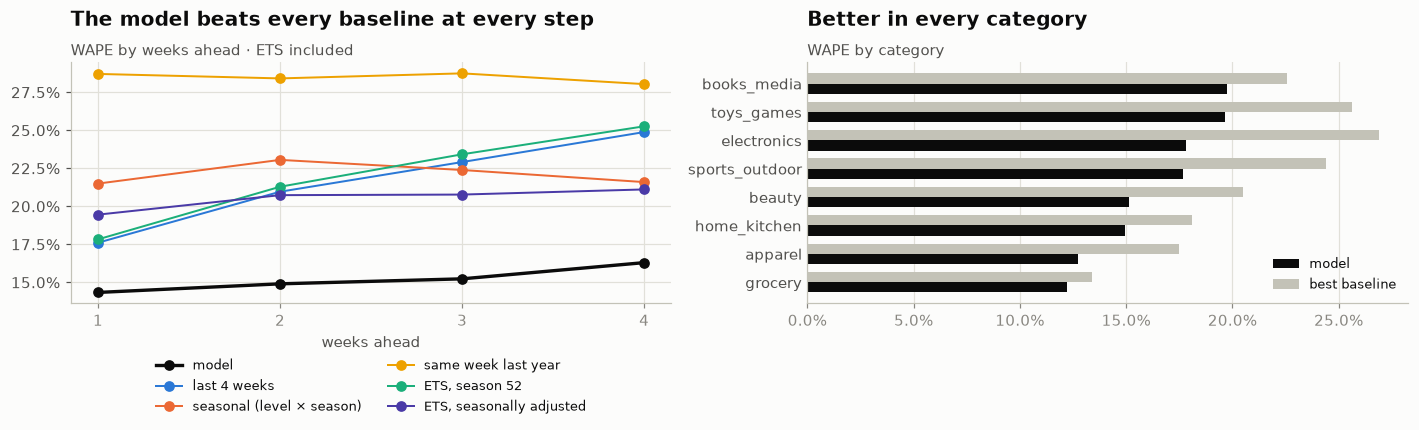

In [20]:
# Step 16 — where the 4-week model wins
R4 = RUNS["B · stockouts filled"].merge(ETS[4], on=["sku_i", "c", "t"], how="left")
compare = {"model": R4.pred, **baselines(R4)}
display(score(R4, compare).style.format({"WAPE": "{:.1%}", "bias": "{:+.1%}"}))
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
for i, (n, p) in enumerate(compare.items()):
    by_h = R4.assign(p=p).groupby("h").apply(lambda g: wape(g.truth, g.p), include_groups=False)
    a1.plot(by_h.index, by_h.values, marker="o", color=[INK, CAT[0], CAT[1], CAT[3], CAT[2], CAT[6]][i], lw=2.2 if n == "model" else 1.3, label=n)
a1.set_xticks([1, 2, 3, 4]); a1.set_xlabel("weeks ahead"); a1.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1))
a1.legend(fontsize=8.5, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.18))
headline(a1, "The model beats every baseline at every step", "WAPE by weeks ahead · ETS included")
by_cat = R4.groupby("cat").apply(lambda g: pd.Series({"model": wape(g.truth, g.pred), "best baseline": min(wape(g.truth, b) for b in baselines(g).values())}), include_groups=False)
by_cat.index = [CATS[i] for i in by_cat.index]; by_cat = by_cat.sort_values("model")
y = np.arange(len(by_cat))
a2.barh(y - 0.18, by_cat["model"], height=0.36, color=INK, label="model")
a2.barh(y + 0.18, by_cat["best baseline"], height=0.36, color=AXIS, label="best baseline")
a2.set_yticks(y, by_cat.index); a2.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); a2.legend(fontsize=8.5)
headline(a2, "Better in every category", "WAPE by category", hbar=True)
plt.tight_layout(); plt.show()

## Step 17 — Where it fails: products entering their final decline

In [21]:
# Step 17 — split the error by lifecycle stage (is_declining is used only to diagnose, never as a feature)
decl = df.set_index([df.sku.map(si), df.date.map(wi)]).is_declining
R4["stage"] = np.where(decl.reindex(list(zip(R4.sku_i, R4.t))).to_numpy() == 1, "final decline", "launch / mature")
stage = R4.groupby("stage").apply(lambda g: pd.Series({"share of rows": len(g) / len(R4), "WAPE": wape(g.truth, g.pred), "bias": bias(g.truth, g.pred)}), include_groups=False)
stage.style.format({"share of rows": "{:.0%}", "WAPE": "{:.1%}", "bias": "{:+.1%}"})

,share of rows,WAPE,bias
stage,,,
final decline,13%,48.8%,+42.0%
launch / mature,87%,13.2%,-3.9%


> **Key idea 7 · dying products are over-forecast by +42%**  
> A product that starts its final decline inside the forecast window gets over-forecast, +42% at 4 weeks and +72% at 3 months (Step 20): nothing in its history announces the decline. The `trend` feature catches it only once sales have already started to slide. In a warehouse that means dead stock and markdowns, so the promo planner warns when a product's sales are already slowing.

## Step 18 — What the model relies on

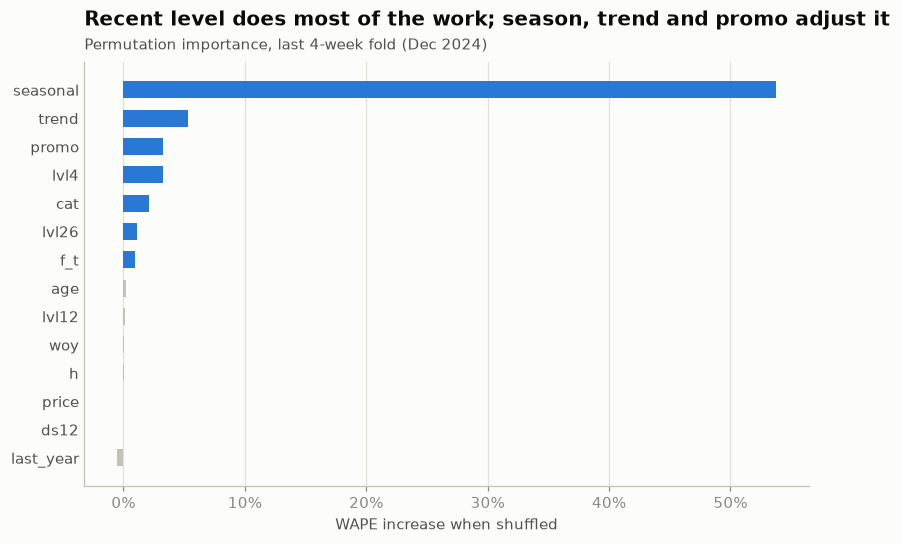

In [22]:
# Step 18 — permutation importance on the scored weeks: how much WAPE worsens when a feature is shuffled
final_fold = R4[R4.c == FOLDS[4][-1]]
m4 = fit(ROWS[("B", 4)][ROWS[("B", 4)].t <= FOLDS[4][-1]])
imp = permutation_importance(m4, final_fold[FEATS], final_fold.truth, n_repeats=5, random_state=SEED,
                             scoring=lambda est, X, y: -wape(y.to_numpy(), predict(est, X)))
imp = pd.Series(imp.importances_mean, index=FEATS).sort_values()
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(imp.index, imp.values, color=[CAT[0] if v > 0.005 else AXIS for v in imp.values], height=0.6)
ax.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); ax.set_xlabel("WAPE increase when shuffled")
headline(ax, "Recent level does most of the work; season, trend and promo adjust it", "Permutation importance, last 4-week fold (Dec 2024)", hbar=True)
plt.show()

---
# Phase 5 — 3-month model (13 weeks)

## Step 19 — A separate model for the long horizon

,WAPE,bias
model,18.9%,-3.2%
last 4 weeks,29.5%,+4.4%
seasonal (level × season),23.8%,+0.4%
same week last year,27.9%,-5.1%
"ETS, season 52",33.7%,+6.7%
"ETS, seasonally adjusted",25.3%,+2.5%


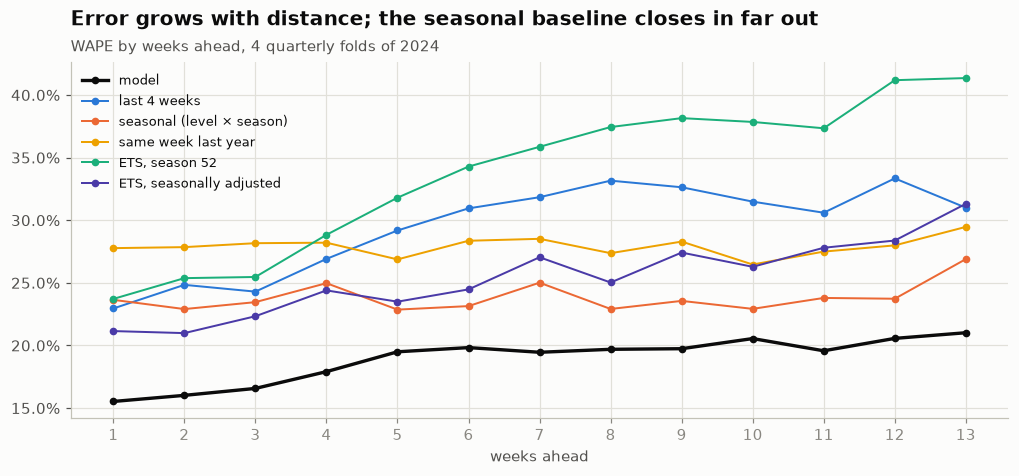

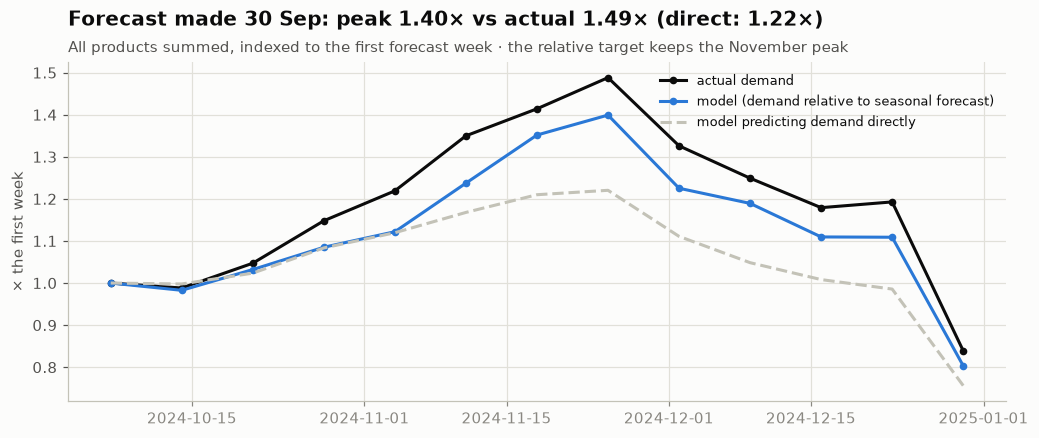

,share of rows,WAPE,bias
stage,,,
final decline,10%,76.2%,+71.7%
launch / mature,90%,15.9%,-7.2%


In [23]:
# Step 19 — trained on 1–13 weeks ahead, so it learns how much recent momentum still matters 3 months out
ROWS[("B", 13)] = attach(features_all(FILLED, 13), FILLED)
R13 = backtest(ROWS[("B", 13)], FOLDS[13], p90=True).merge(ETS[13], on=["sku_i", "c", "t"], how="left")
R13["stage"] = np.where(decl.reindex(list(zip(R13.sku_i, R13.t))).to_numpy() == 1, "final decline", "launch / mature")
compare13 = {"model": R13.pred, **baselines(R13)}
display(score(R13, compare13).style.format({"WAPE": "{:.1%}", "bias": "{:+.1%}"}))
fig, ax = plt.subplots(figsize=(11, 4.2))
for i, (n, p) in enumerate(compare13.items()):
    by_h = R13.assign(p=p).groupby("h").apply(lambda g: wape(g.truth, g.p), include_groups=False)
    ax.plot(by_h.index, by_h.values, marker="o", ms=4, color=[INK, CAT[0], CAT[1], CAT[3], CAT[2], CAT[6]][i], lw=2.2 if n == "model" else 1.3, label=n)
ax.set_xticks(range(1, 14)); ax.set_xlabel("weeks ahead"); ax.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); ax.legend(fontsize=8.5)
headline(ax, "Error grows with distance; the seasonal baseline closes in far out", "WAPE by weeks ahead, 4 quarterly folds of 2024")
plt.show()
# Same fold (forecast made 30 Sep 2024), one model trained the old way: predicting demand directly
C = FOLDS[13][-1]
X13 = ROWS[("B", 13)]
direct = X13[X13.c == C].assign(direct=lambda d: predict(fit(X13[X13.t <= C], relative=False), d))
shape = R13[R13.c == C].merge(direct[["sku_i", "t", "direct"]], on=["sku_i", "t"]).groupby("t")[["truth", "pred", "direct"]].sum()
shape = shape / shape.iloc[0]
fig, ax = plt.subplots(figsize=(11, 4))
x = WEEKS[shape.index.to_numpy()]
ax.plot(x, shape.truth, color=INK, lw=2, marker="o", ms=4, label="actual demand")
ax.plot(x, shape.pred, color=CAT[0], lw=2, marker="o", ms=4, label="model (demand relative to seasonal forecast)")
ax.plot(x, shape.direct, color=AXIS, lw=2, ls="--", label="model predicting demand directly")
ax.set_ylabel("× the first week"); ax.legend(fontsize=8.5, loc="upper right")
headline(ax, f"Forecast made 30 Sep: peak {shape.pred.max():.2f}× vs actual {shape.truth.max():.2f}× (direct: {shape.direct.max():.2f}×)",
         "All products summed, indexed to the first forecast week · the relative target keeps the November peak")
plt.show()
R13.groupby("stage").apply(lambda g: pd.Series({"share of rows": len(g) / len(R13), "WAPE": wape(g.truth, g.pred), "bias": bias(g.truth, g.pred)}), include_groups=False) \
    .style.format({"share of rows": "{:.0%}", "WAPE": "{:.1%}", "bias": "{:+.1%}"})

## Step 20 — The scorecard a planner asks for
One weekly WAPE hides things that matter in a warehouse: how accurate the **horizon total** is (what replenishment orders against), how errors
weigh in **revenue**, how the error **spreads across products**, how the model does **in peak season**, and whether the overall bias is two
opposite errors cancelling out.

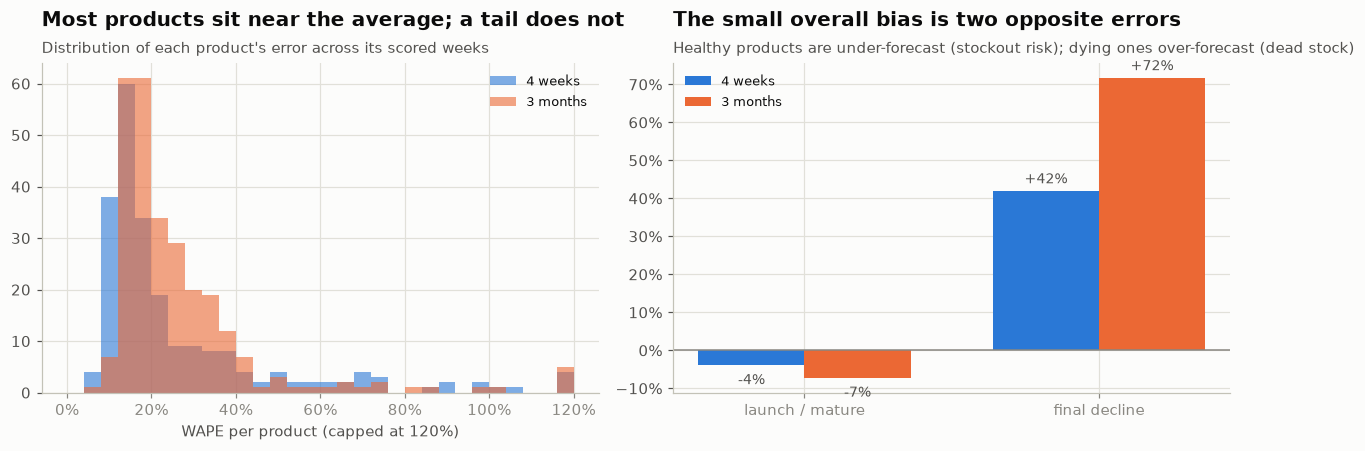

,4 weeks,3 months
"WAPE, weekly",15.2%,18.9%
"WAPE, horizon total",11.3%,13.2%
"WAPE, revenue-weighted",16.2%,19.5%
"WAPE, median product",17.3%,20.5%
"WAPE, worst 10% of products",58.9%,40.1%
"WAPE, Nov–Dec weeks",13.4%,20.3%
"WAPE, other weeks",16.4%,18.6%
"bias, overall",-1.3%,-3.2%
"bias, launch / mature",-3.9%,-7.2%
"bias, final decline",+42.0%,+71.7%


In [24]:
# Step 20 — planner scorecard for both horizons
def scorecard(r):
    tot = r.groupby(["sku_i", "c"])[["truth", "pred"]].sum()
    per_sku = r.groupby("sku_i").apply(lambda g: wape(g.truth, g.pred), include_groups=False)
    peak = np.isin(WEEKS[r.t.to_numpy()].month, [11, 12])
    price = PRICE[r.sku_i]
    by_stage = r.groupby("stage").apply(lambda g: bias(g.truth, g.pred), include_groups=False)
    return pd.Series({
        "WAPE, weekly": wape(r.truth, r.pred),
        "WAPE, horizon total": wape(tot.truth, tot.pred),
        "WAPE, revenue-weighted": np.abs(r.truth - r.pred).mul(price).sum() / r.truth.mul(price).sum(),
        "WAPE, median product": per_sku.median(),
        "WAPE, worst 10% of products": per_sku.quantile(0.9),
        "WAPE, Nov–Dec weeks": wape(r[peak].truth, r[peak].pred),
        "WAPE, other weeks": wape(r[~peak].truth, r[~peak].pred),
        "bias, overall": bias(r.truth, r.pred),
        "bias, launch / mature": by_stage["launch / mature"],
        "bias, final decline": by_stage["final decline"],
    })

CARD = pd.DataFrame({"4 weeks": scorecard(R4), "3 months": scorecard(R13)})
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2))
for i, (n, r) in enumerate([("4 weeks", R4), ("3 months", R13)]):
    per_sku = r.groupby("sku_i").apply(lambda g: wape(g.truth, g.pred), include_groups=False).clip(upper=1.2)
    a1.hist(per_sku, bins=30, range=(0, 1.2), alpha=0.6, color=CAT[i], label=n)
a1.xaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); a1.set_xlabel("WAPE per product (capped at 120%)"); a1.legend(fontsize=8.5)
headline(a1, "Most products sit near the average; a tail does not", "Distribution of each product's error across its scored weeks")
stage_bias = CARD.loc[["bias, launch / mature", "bias, final decline"]]
x = np.arange(2)
for i, col in enumerate(CARD.columns):
    a2.bar(x + (i - 0.5) * 0.36, stage_bias[col], width=0.36, color=CAT[i], label=col)
    for xi, v in zip(x + (i - 0.5) * 0.36, stage_bias[col]):
        a2.text(xi, v + (0.02 if v >= 0 else -0.05), f"{v:+.0%}", ha="center", fontsize=9, color=INK_2)
a2.axhline(0, color=MUTED, lw=1); a2.set_xticks(x, ["launch / mature", "final decline"]); a2.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); a2.legend(fontsize=8.5)
headline(a2, "The small overall bias is two opposite errors", "Healthy products are under-forecast (stockout risk); dying ones over-forecast (dead stock)")
plt.tight_layout(); plt.show()
CARD.style.format("{:+.1%}", subset=pd.IndexSlice[[i for i in CARD.index if i.startswith("bias")], :]) \
    .format("{:.1%}", subset=pd.IndexSlice[[i for i in CARD.index if i.startswith("WAPE")], :])

*Reading it as a planner: the **horizon total** is more accurate than any single week, because weekly misses partly cancel. Errors weigh
**more in revenue** than in units (they sit in high-price products). The 3-month model is **least accurate in Nov–Dec**, which is exactly
when a Q4 pre-buy is decided on a ~13-week view. The overall bias is small only because healthy products run under and dying ones run over.*

---
# Phase 6 — p90: how much demand to plan for

## Step 21 — Weekly p90
A second model per horizon predicts each week's 90th percentile (quantile loss). If honest, actual demand lands at or below it ~90% of the time.

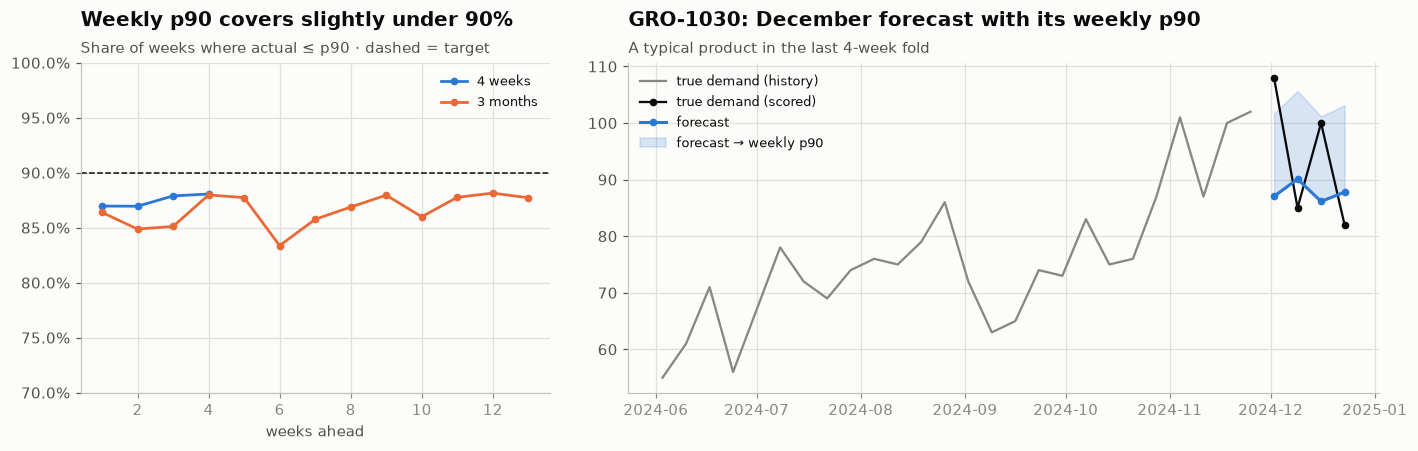

,coverage,p90 ÷ forecast
4 weeks,87.5%,1.23×
3 months,86.6%,1.28×


In [25]:
# Step 21 — weekly p90 coverage in the backtests
cov = pd.DataFrame({
    "4 weeks": {"coverage": (R4.truth <= R4.p90).mean(), "p90 ÷ forecast": (R4.p90.sum() / R4.pred.sum())},
    "3 months": {"coverage": (R13.truth <= R13.p90).mean(), "p90 ÷ forecast": (R13.p90.sum() / R13.pred.sum())},
}).T
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1, 1.6]})
for i, (n, r) in enumerate([("4 weeks", R4), ("3 months", R13)]):
    by_h = r.groupby("h").apply(lambda g: (g.truth <= g.p90).mean(), include_groups=False)
    a1.plot(by_h.index, by_h.values, marker="o", ms=4, color=CAT[i], lw=1.8, label=n)
a1.axhline(0.9, color=INK, ls="--", lw=1); a1.set_ylim(0.7, 1); a1.set_xlabel("weeks ahead")
a1.yaxis.set_major_formatter(mpl.ticker.PercentFormatter(1)); a1.legend(fontsize=8.5)
headline(a1, "Weekly p90 covers slightly under 90%", "Share of weeks where actual ≤ p90 · dashed = target")
# a typical case: among the busier half of products, the one whose error is closest to the overall fold error
last = R4[R4.c == FOLDS[4][-1]]
per = last.groupby("sku_i").apply(lambda g: pd.Series({"vol": g.truth.sum(), "err": wape(g.truth, g.pred)}), include_groups=False)
per = per[per.vol >= per.vol.median()]
k = (per.err - wape(last.truth, last.pred)).abs().idxmin()
hist_w = list(range(FOLDS[4][-1] - 25, FOLDS[4][-1] + 1))
ex = R4[(R4.sku_i == k) & (R4.c == FOLDS[4][-1])]
a2.plot(WEEKS[hist_w], TRUE[k, hist_w], color=MUTED, lw=1.5, label="true demand (history)")
a2.plot(WEEKS[ex.t.to_numpy()], ex.truth, color=INK, lw=1.5, marker="o", ms=4, label="true demand (scored)")
a2.plot(WEEKS[ex.t.to_numpy()], ex.pred, color=CAT[0], lw=2, marker="o", ms=4, label="forecast")
a2.fill_between(WEEKS[ex.t.to_numpy()], ex.pred, ex.p90, color=CAT[0], alpha=0.18, label="forecast → weekly p90")
a2.legend(fontsize=8.5, loc="upper left")
headline(a2, f"{SKUS[k]}: December forecast with its weekly p90", "A typical product in the last 4-week fold")
plt.tight_layout(); plt.show()
cov.style.format({"coverage": "{:.1%}", "p90 ÷ forecast": "{:.2f}×"})

*Weekly coverage lands at ~87%. A calibration learned on earlier folds didn't hold steady across horizons (it overshot the 3-month model to 94%), so the weekly p90 is reported as measured.*

## Step 22 — p90 of the horizon total (what to plan the buy around)
**Adding up weekly p90s is the wrong number for a buy:** weekly misses partly cancel over 4 or 13 weeks, so the sum covers far more than 90% of
horizon totals. **Decision:** p90 of the total = forecast total × a factor learned from backtest errors on
horizon totals, separately for one product and for a whole category (a category's total is steadier). Its coverage is measured
leave-one-fold-out: each fold is scored with a factor learned from the other folds only.

> **Key idea 8 · plan to the p90 of the total**  
> Adding weekly p90s covers 96–97% of horizon totals, not 90%. The p90 of the total is the honest number: ~90% for one product, and far less stock for a whole category.

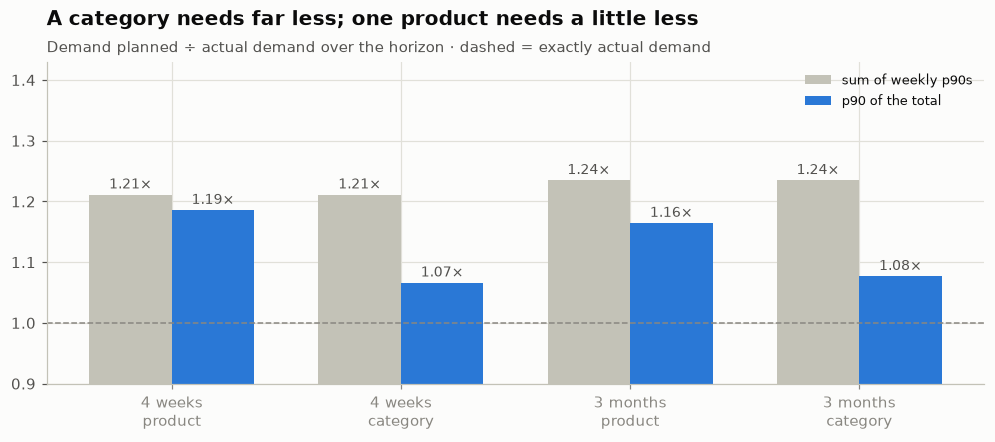

In [26]:
# Step 22 — horizon-total p90 factors, product and category level
def totals(r, level):
    keys = ["sku_i", "c"] if level == "product" else ["cat", "c"]
    return r.groupby(keys)[["truth", "pred", "p90"]].sum().reset_index()

def factor(t):
    return np.quantile(t.truth / t.pred, 0.9)

rows, FACTORS = [], []
for H, r in [(4, R4), (13, R13)]:
    for level in ["product", "category"]:
        t = totals(r, level)
        lofo = [(f.truth <= f.pred * factor(t[t.c != c])).mean() for c, f in t.groupby("c")]  # leave one fold out
        f_all = factor(t)
        FACTORS.append({"horizon": "4 weeks" if H == 4 else "3 months", "level": level, "factor": round(f_all, 3)})
        rows.append({"horizon": "4 weeks" if H == 4 else "3 months", "level": level,
                     "sum of weekly p90: covers": (t.truth <= t.p90).mean(), "sum of weekly p90 ÷ actual": t.p90.sum() / t.truth.sum(),
                     "total p90 factor": f_all, "total p90: covers (out of fold)": np.mean(lofo),
                     "total p90 ÷ actual": (t.pred * f_all).sum() / t.truth.sum()})
TOTALS = pd.DataFrame(rows).set_index(["horizon", "level"])
fig, ax = plt.subplots(figsize=(11, 3.8))
labels = [f"{h}\n{l}" for h, l in TOTALS.index]
x = np.arange(len(TOTALS))
ax.bar(x - 0.18, TOTALS["sum of weekly p90 ÷ actual"], width=0.36, color=AXIS, label="sum of weekly p90s")
ax.bar(x + 0.18, TOTALS["total p90 ÷ actual"], width=0.36, color=CAT[0], label="p90 of the total")
for xi, (a, b) in zip(x, TOTALS[["sum of weekly p90 ÷ actual", "total p90 ÷ actual"]].values):
    ax.text(xi - 0.18, a + 0.01, f"{a:.2f}×", ha="center", fontsize=9, color=INK_2); ax.text(xi + 0.18, b + 0.01, f"{b:.2f}×", ha="center", fontsize=9, color=INK_2)
ax.axhline(1, color=MUTED, lw=1, ls="--"); ax.set_xticks(x, labels); ax.set_ylim(0.9, max(TOTALS.max(numeric_only=True).iloc[:2].max(), 1.35) + 0.08); ax.legend(fontsize=8.5)
headline(ax, "A category needs far less; one product needs a little less", "Demand planned ÷ actual demand over the horizon · dashed = exactly actual demand")
plt.show()
TOTALS.style.format({"sum of weekly p90: covers": "{:.1%}", "sum of weekly p90 ÷ actual": "{:.2f}×", "total p90 factor": "{:.3f}",
                     "total p90: covers (out of fold)": "{:.1%}", "total p90 ÷ actual": "{:.2f}×"})

*For **one product**, the total p90 plans 2–8% less than adding weekly p90s, and its coverage is honest: ~90% instead of 96–97%. For a **whole category** it plans far less (1.07–1.08× actual instead of 1.21–1.24×), because errors across products cancel. Category coverage comes out under target (84–88%) since each fold gives only 8 category totals to learn from, so treat it as rough. The planner shows the total p90 as “demand to plan for”: a demand figure, not an order quantity, because the data has no on-hand stock or lead times.*

---
# Phase 7 — Final models and the forecasts behind the promo planner

## Step 23 — Train on all history, forecast from the last week, with and without a promo
Promo effects don't carry over between weeks (the week after a promo sells at normal levels), so each future week is forecast twice: promo off
and promo on. The planner picks one per week from the PM's input, which gives exactly the model's answer without running the model in the browser.
Two more columns go with each product: its **return rate** (so planner revenue is net of returns, like the sales dashboard) and its current
**sales trend** (last 4 ÷ last 12 weeks, seasonality removed), so the planner can warn when a product may be entering its decline.

> **Key idea 9 · promo forecasts are precomputed, and that is exact**  
> In the data, the week after a promo sells at its normal level (−0.6%), so a promo changes only its own weeks. Forecasting every week twice, promo off and on, covers every plan a PM can enter, and the planner needs no model running in the browser.

**See it in action:** <a href="../#forecast-app" target="_top"><b>Open the promo planner →</b></a>

In [27]:
# Step 23 — 4 final models → data/forecasts.csv, plus data/p90_factors.csv
last_c = len(WEEKS) - 1
return_rate = df.groupby("category").returns.sum() / df.groupby("category").units_sold.sum()
parts = []
for H, label in [(4, "4 weeks"), (13, "3 months")]:
    train = ROWS[("B", H)]
    point, upper = fit(train), fit(train, 0.9)
    F = make_features(FILLED, last_c, H)
    for promo in (0, 1):
        X = F.assign(promo=promo)
        parts.append(pd.DataFrame({
            "sku": np.array(SKUS)[X.sku_i], "horizon": label, "week": WEEKS[-1] + pd.to_timedelta(X.h * 7, unit="D"),
            "h": X.h, "promo": promo, "forecast": predict(point, X).round(1), "p90": predict(upper, X).round(1),
            "trend": X.trend.round(3),
        }))
forecasts = pd.concat(parts, ignore_index=True).merge(info[["category", "region", "price"]], left_on="sku", right_index=True)
forecasts["return_rate"] = forecasts.category.map(return_rate).round(4)
forecasts["p90"] = forecasts[["forecast", "p90"]].max(axis=1)  # a p90 below the forecast would read as nonsense
forecasts.to_csv("data/forecasts.csv", index=False)
pd.DataFrame(FACTORS).to_csv("data/p90_factors.csv", index=False)
n_live = ALIVE[:, last_c].sum()
assert len(forecasts) == n_live * (4 + 13) * 2
slowing = forecasts.drop_duplicates("sku").trend.lt(0.8).sum()
print(f"data/forecasts.csv: {len(forecasts):,} rows = {n_live} products on sale × (4 + 13 weeks) × promo off/on · {slowing} products with sales slowing (trend < 0.8)")
uplift = forecasts.pivot_table(index="category", columns="promo", values="forecast", aggfunc="sum")
(uplift[1] / uplift[0] - 1).sort_values().rename("forecast uplift from a promo").to_frame().style.format("{:+.0%}")

data/forecasts.csv: 5,338 rows = 157 products on sale × (4 + 13 weeks) × promo off/on · 1 products with sales slowing (trend < 0.8)


,forecast uplift from a promo
category,
grocery,+15%
books_media,+18%
home_kitchen,+18%
sports_outdoor,+21%
beauty,+31%
apparel,+40%
electronics,+50%
toys_games,+51%


*The models learned promo lifts in line with Step 9, so the planner's promo switch moves forecasts by believable amounts.*

## Step 24 — Limits
**Model**
- **Synthetic data.** Results show the method works; revalidate on real sales before relying on the numbers.
- **Declining products are over-forecast** (Step 17, Step 20): a decline that starts inside the window can't be seen from history. The planner flags products whose sales are already slowing.
- **The 3-month model is weakest in Nov–Dec** (Step 20), the season a Q4 pre-buy is planned for.
- **Promo = 25% off only.** It is the only discount in the data. **Category-wide promos are outside the history** (a category was more than half on promo in only 2 weeks), so the planner's category promo result ignores cannibalization between products and is an upper bound.
- **Weekly p90 covers ~87%** (Step 21); the horizon-total p90 is calibrated on backtests (Step 22).
- **New launches are not forecast.** No product launched in the 2024 test window, so a cold-start model couldn't be scored.

**What a production setup would add**
- **Weekly retraining.** These forecasts are a snapshot from 30 Dec 2024 and go stale week by week.
- **Order quantities.** Turning demand into a buy needs on-hand stock, lead times and order minimums, none of which are in the data.
- **Substitution.** Demand lost in a stockout is treated as lost; in reality some of it moves to a similar product.
- **Chosen promos.** Promos here were random. In real data they are picked for products and weeks expected to sell, which inflates measured uplift unless handled.